Primero uso del cv2


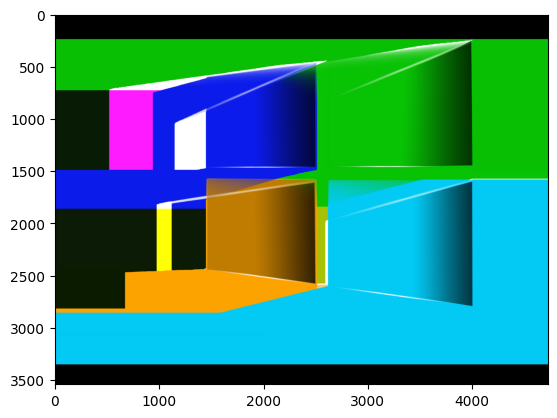

tamanio (3543, 4724, 3)


In [1]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('windows.png')

plt.imshow(img)
plt.show()

print('tamanio', img.shape)

¿Por qué se ve así?
El problema principal aquí no es solo el color (que también influye), sino el formato de transparencia (Canal Alfa).

La imagen original es un .png con fondo transparente: Los archivos PNG suelen tener 4 canales: Rojo, Verde, Azul y Alfa (transparencia).

OpenCV (cv2.imread) por defecto solo lee 3 canales: Al leerla de forma normal, OpenCV ignora la transparencia o la interpreta como datos de color extra, lo que causa esos bloques de colores neón y la distorsión que ves.

El orden de colores BGR vs RGB: Como te mencioné al principio, OpenCV lee en Azul-Verde-Rojo, mientras que Matplotlib espera Rojo-Verde-Azul. Por eso lo que debería ser rojo se ve azul.

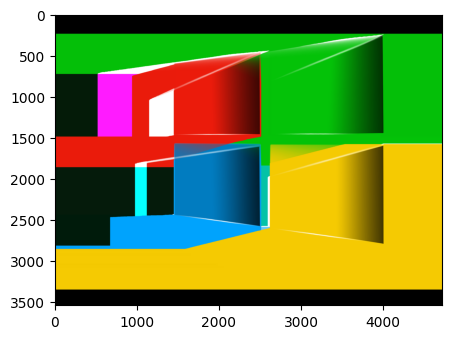

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (5, 5)
img = cv2.imread('windows.png')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(imgRGB)
plt.show()

ploteo por canales  separado 


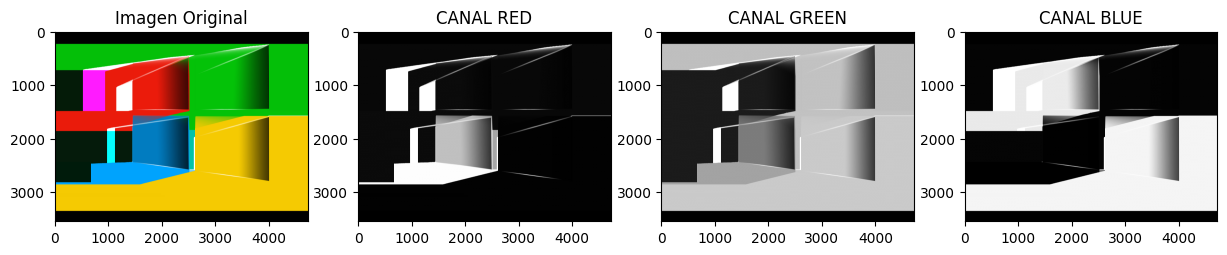

In [4]:
import cv2
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (15, 15)
img = cv2.imread('windows.png', cv2.IMREAD_COLOR)

# IMAGEN ORIGINAL Y DIVIDIDA EN CANALES

plt.subplot(141)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# CANAL ROJO DEL RGB
plt.subplot(142)
plt.title('CANAL RED')
plt.imshow(img[:,:,0], cmap='gray') # Reds

# CANAL VERDE DEL RGB
plt.subplot(143)
plt.title('CANAL GREEN')
plt.imshow(img[:,:,1], cmap='gray') # Greens

# CANAL AZUL DEL RGB
plt.subplot(144)
plt.title('CANAL BLUE')
plt.imshow(img[:,:,2], cmap='gray') # Blues

plt.show()

con colores relleno 

(np.float64(-0.5), np.float64(4723.5), np.float64(3542.5), np.float64(-0.5))

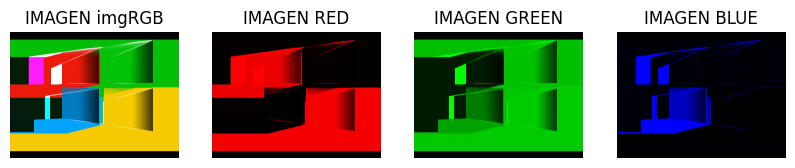

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (15, 15)
img = cv2.imread('windows.png', cv2.IMREAD_COLOR)
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Colocamos de 2 a 0 por que es BGR
red_BRG = img[:,:,2]
green_BRG = img[:,:,1]
blue_BRG = img[:,:,0]

# CREAR POR CANAL
red_img = np.zeros_like(imgRGB)
red_img[:,:,0] = red_BRG

green_img = np.zeros_like(imgRGB)
green_img[:,:,1] = green_BRG

blue_img = np.zeros_like(imgRGB)
blue_img[:,:,2] = blue_BRG

plt.figure(figsize=(10, 5))
plt.subplot(141)
plt.title('IMAGEN imgRGB')
plt.imshow(imgRGB)
plt.axis('off')

plt.subplot(142)
plt.title('IMAGEN RED')
plt.imshow(red_img)
plt.axis('off')

plt.subplot(143)
plt.title('IMAGEN GREEN')
plt.imshow(green_img)
plt.axis('off')

plt.subplot(144)
plt.title('IMAGEN BLUE')
plt.imshow(blue_img)
plt.axis('off')

Generacion de falso color con CMAP

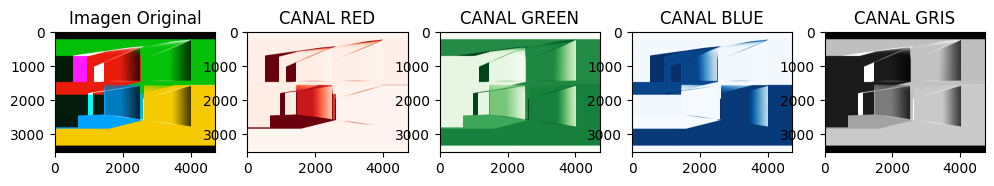

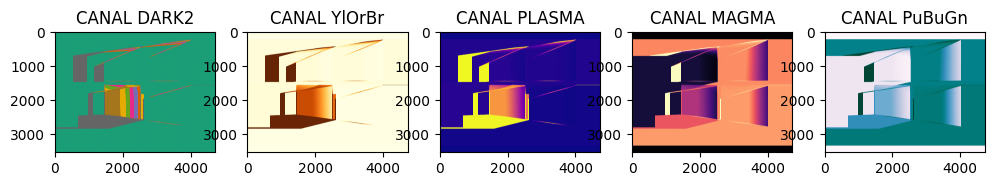

In [8]:
import cv2
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 12)
img = cv2.imread('windows.png', cv2.IMREAD_COLOR)

# CREAR 10 imagenes con diferentes colormaps para el canal rojo del RGB en 2 filas

###########################################################

plt.subplot(1, 5, 1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# CANAL ROJO DEL RGB
plt.subplot(1, 5, 2)
plt.title('CANAL RED')
plt.imshow(img[:,:,0], cmap='Reds') # Reds

# CANAL VERDE DEL RGB
plt.subplot(1, 5, 3)
plt.title('CANAL GREEN')
plt.imshow(img[:,:,1], cmap='Greens') # Greens

# CANAL AZUL DEL RGB
plt.subplot(1, 5, 4)
plt.title('CANAL BLUE')
plt.imshow(img[:,:,2], cmap='Blues') # Blues

# CANAL GRIS DE LA IMAGEN
plt.subplot(1, 5, 5)
plt.title('CANAL GRIS')
plt.imshow(img[:,:,1], cmap='gray')

plt.show() # importante para separar filas

###########################################################

plt.subplot(2, 5,1)
plt.title('CANAL DARK2')
plt.imshow(img[:,:,0], cmap='Dark2')

plt.subplot(2, 5, 2)
plt.title('CANAL YlOrBr')
plt.imshow(img[:,:,0], cmap='YlOrBr')

plt.subplot(2, 5, 3)
plt.title('CANAL PLASMA')
plt.imshow(img[:,:,0], cmap='plasma')

plt.subplot(2, 5, 4)
plt.title('CANAL MAGMA')
plt.imshow(img[:,:,1], cmap='magma')

plt.subplot(2, 5, 5)
plt.title('CANAL PuBuGn')
plt.imshow(img[:,:,1], cmap='PuBuGn')

plt.show()

1. Configuración Inicial y Lectura
plt.rcParams['figure.figsize'] = (12, 12): Define que el tamaño de la ventana donde saldrán las imágenes sea de 12x12 pulgadas. Esto ayuda a que las miniaturas no se vean amontonadas.

cv2.imread('windows.png', cv2.IMREAD_COLOR): Carga la imagen en formato BGR (Blue-Green-Red). Es importante recordar que para OpenCV, el canal 0 es Azul, el 1 es Verde y el 2 es Rojo.

2. Primera Fila: Descomposición de Canales
En esta sección se usa plt.subplot(1, 5, X) para crear una fila con 5 columnas.

Imagen Original: Se usa cv2.cvtColor(img, cv2.COLOR_BGR2RGB) porque Matplotlib necesita el orden RGB para mostrar los colores reales.

Extracción de Canales: Aquí hay un detalle técnico importante en tu código. Cuando haces img[:,:,X], estás accediendo a la matriz de píxeles:

img[:,:,0]: Es el canal Azul (aunque tu título diga RED, por el formato BGR de OpenCV).

img[:,:,1]: Es el canal Verde.

img[:,:,2]: Es el canal Rojo.

Colormaps (cmap): Se usan mapas de colores temáticos (Reds, Greens, Blues) para que visualmente identifiques qué tanta intensidad de ese color hay en cada zona. Las partes más oscuras del mapa de color indican valores cercanos a 0, y las más intensas valores cercanos a 255.

3. Segunda Fila: Experimentación con Colormaps
Aquí el código cambia a plt.subplot(2, 5, X), preparando una cuadrícula de 2 filas por 5 columnas. El objetivo es mostrar cómo una matriz de escala de grises (un solo canal) puede "pintarse" con colores falsos para resaltar detalles.

¿Qué es un Colormap?: Básicamente le dice a Python: "Si el píxel vale 0 (negro), píntalo de color A; si vale 255 (blanco), píntalo de color B".

Los estilos usados:

Dark2: Un mapa cualitativo (colores planos).

YlOrBr: Yellow-Orange-Brown (útil para mapas de calor).

Plasma / Magma: Mapas "perceptualmente uniformes", muy usados en ciencia para ver variaciones sutiles que el ojo humano no nota en gris.

⚠️ Observación importante en tu código
Hay una pequeña confusión con los índices que podrías corregir para que tus laboratorios sean exactos:

Índices BGR: Como usaste cv2.imread, los índices reales son:

img[:,:,0] → Azul

img[:,:,1] → Verde

img[:,:,2] → Rojo

En tu código pusiste img[:,:,0] con el título "CANAL RED". Si quieres que sea realmente el rojo, deberías usar el índice 2.

Uso de subplots: Al pasar de la primera sección a la segunda, cambias de (1, 5, X) a (2, 5, X). Es buena práctica usar siempre la misma estructura de cuadrícula (por ejemplo, definir (2, 5, X) desde el principio) para que todas las imágenes mantengan el mismo tamaño relativo